In [ ]:
USER = "varom"

import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import os 
import seaborn as sns

path_root = '/data/at3/common/EWK2L3L_ANA-SUSY-2024-02/FFntuples/RUN2_v2'

#SUSY MC signal ---------------------------------------------------------------------------

#file_C1N2_WZ_2L = f"{path_root}/SIGNAL/C1N2_WZ_2L_569622_mc20a_fastsim.root"
file_C1N2_WZ_2L = f'{path_root}/C1N2_WZ_2L_569238_mc20e_fastsim.root'

#SM MC background --------------------------------------------------------------------------

#file_VVV = f'{path_root}/VVV_701235_mc20a_fullsim.root'
file_VVV = f"{path_root}/VVV_701235_mc20e_fullsim.root"

#file_VV = f'{path_root}/VV_Sh2212_700600_mc20a_fullsim.root'
file_VV = f'{path_root}/VV_Sh2212_700600_mc20e_fullsim.root'

file_Vy = f'{path_root}/Vy_Sh2214_700770_mc20e_fullsim.root'

file_Wjets_lv = f'{path_root}/Wjets_lv_700338_mc20e_fullsim.root'

#file_Zjets_ll = f'{path_root}/Zjets_ll_700320_mc20a_fullsim.root'
file_Zjets_ll = f'{path_root}/Zjets_ll_700320_mc20e_fullsim.root'

file_Zjets_lowMLL = f'{path_root}/Zjets_lowMLL_700467_mc20e_fullsim.root'

file_higgs = f'{path_root}/higgs_345097_mc20e_fullsim.root'

file_othertop = f'{path_root}/othertop_304014_mc20e_fullsim.root'

file_ttbar_allhad = f'{path_root}/ttbar_allhad_410471_mc20e_fullsim.root'

file_ttbar_dil = f'{path_root}/ttbar_dil_410472_mc20e_fullsim.root'

file_ttbar_nonallhad = f'{path_root}/ttbar_nonallhad_410470_mc20e_fullsim.root'


contar una vez repesados
normalizar las graficas una vez stackeadas

In [2]:
import uproot
import awkward as ak

# ROOT TO PANDAS BUT USING UPROOT (FLATTENS THE DATA IN CASE THERE ARE MULTIPLE CANDIDATES)

def convert_ROOT_to_pd(filename,cols):
    #Convierte un ROOT file a un DataFrame de pandas de manera segura,incluso si contiene columnas vectoriales.
    
    with uproot.open(filename) as f:
        tree = f["analysis"]

        if cols == None:
            all_columns = tree.keys()
        else:
            all_columns = cols

        arr = tree.arrays(all_columns, library="ak")
        df = ak.to_dataframe(arr).copy()
    return df


In [3]:
columns = ['L2_RJ_R_ISR_NOSYS','L2_mt2_NOSYS','L2_mt2100_NOSYS','met_GeV_NOSYS','jet_n_NOSYS',
    #'ljet_n_NOSYS','bjet_n_NOSYS',
    'L2_dR_ll_NOSYS', 'L2_dPhi_ll_NOSYS', 'L2_dPhi_METj_NOSYS', 'L2_ptll_NOSYS','weight_total_NOSYS','L2_mll_NOSYS','L2_mSFOS_NOSYS',
    'L2_RJ_ISR_pt_NOSYS','L2_RJ_MTS_NOSYS','lep1_pt_NOSYS','lep2_pt_NOSYS','lep3_pt_NOSYS']

In [4]:
df_C1N2_WZ_2L = convert_ROOT_to_pd(file_C1N2_WZ_2L,columns)
df_VV = convert_ROOT_to_pd(file_VV,columns)

In [5]:
df_ttbar_nonallhad = convert_ROOT_to_pd(file_ttbar_nonallhad,columns)
df_ttbar_dil = convert_ROOT_to_pd(file_ttbar_dil,columns)
df_ttbar_allhad = convert_ROOT_to_pd(file_ttbar_allhad,columns)

In [6]:
df_Zjets_ll = convert_ROOT_to_pd(file_Zjets_ll,columns)

In [7]:
print(f"{df_Zjets_ll.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

5.22 GB


In [8]:
def search_cols(df,word):
    pid_columns = [col for col in df.columns if word in col]

    return pid_columns

In [9]:
#df_C1N2_WZ_2L['PROCESS'] = 0
#df_VV['PROCESS'] = 1
#df_ttbar_nonallhad['PROCESS'] = 2
#df_ttbar_dil['PROCESS'] = 3
#df_ttbar_allhad['PROCESS'] = 4
#df_Zjets_ll['PROCESS'] = 5

#df_tot = pd.concat([df_C1N2_WZ_2L, df_VV,df_ttbar_nonallhad,df_ttbar_dil,df_ttbar_allhad,df_Zjets_ll], ignore_index=True)

In [10]:
def pd_concat_and_process(df_vect):
    # df_vect is a tuple list (see below)

    dfs = []

    for i, (name, df) in enumerate(df_vect):
        df["PROCESS"] = i
        print(f"{name} is PROCESS {i}.")
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

# Concat all of the dataframes ------------------ df_vect is a tuple list

df_vect = [
    ("df_C1N2_WZ_2L", df_C1N2_WZ_2L),
    ("df_VV", df_VV),
    ("df_ttbar_nonallhad", df_ttbar_nonallhad),
    ("df_ttbar_dil", df_ttbar_dil),
    ("df_ttbar_allhad", df_ttbar_allhad),
    ("df_Zjets_ll", df_Zjets_ll),
]

df_tot = pd_concat_and_process(df_vect = df_vect)
print(f"The total df occupies {df_tot.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

# Eliminate the individual dataframes to save memory -------------------------------
del df_C1N2_WZ_2L
del df_VV
del df_ttbar_allhad
del df_ttbar_dil
del df_ttbar_nonallhad
del df_Zjets_ll


df_C1N2_WZ_2L is PROCESS 0.
df_VV is PROCESS 1.
df_ttbar_nonallhad is PROCESS 2.
df_ttbar_dil is PROCESS 3.
df_ttbar_allhad is PROCESS 4.
df_Zjets_ll is PROCESS 5.
The total df occupies 12.86 GB


In [11]:
df_tot['weight_total_NOSYS'].describe()

count    1.327329e+08
mean     4.433189e-02
std      8.318199e-02
min     -1.636576e+02
25%      4.788218e-03
50%      3.533020e-02
75%      4.440750e-02
max      2.842191e+01
Name: weight_total_NOSYS, dtype: float64

# Create new variables and eliminate the unnecessary ones

In [12]:
def new_vars(df):

    # Sum of lepton transverse momentum ------------------- Done like this to optimize memory usage
    df['lep1_pt_NOSYS'] += df['lep2_pt_NOSYS']
    df['lep1_pt_NOSYS'] += df['lep3_pt_NOSYS']

    df.rename(columns={"lep1_pt_NOSYS": "lep_sum_pt_NOSYS"},inplace=True)
    df.drop(columns=['lep2_pt_NOSYS', 'lep3_pt_NOSYS'],inplace=True)

    return df


In [13]:
new_vars(df_tot)

,L2_RJ_R_ISR_NOSYS,L2_mt2_NOSYS,L2_mt2100_NOSYS,met_GeV_NOSYS,jet_n_NOSYS,L2_dR_ll_NOSYS,L2_dPhi_ll_NOSYS,L2_dPhi_METj_NOSYS,L2_ptll_NOSYS,weight_total_NOSYS,L2_mll_NOSYS,L2_mSFOS_NOSYS,L2_RJ_ISR_pt_NOSYS,L2_RJ_MTS_NOSYS,lep_sum_pt_NOSYS,PROCESS
0,0.413082,35.138985,126.019745,48.358875,3,1.338635,0.699486,2.769891,62.554417,0.150113,42.952828,0.0,88.912023,116.769311,65.063202,0
1,0.892223,0.009856,105.818268,20.548430,2,2.874424,-2.838007,3.076384,17.252090,0.113754,81.731677,0.0,22.660170,122.231085,80.452637,0
2,0.413288,56.293037,133.080551,66.214148,2,0.983386,0.064046,-1.409173,71.818581,0.116539,30.429959,0.0,22.898254,138.309393,70.843826,0
3,0.320271,33.393173,124.334801,32.626662,3,2.076919,-2.076919,0.756414,58.805698,0.206960,82.738787,0.0,76.514723,187.780935,100.507477,0
4,0.203309,8.839292,108.844933,7.396448,1,2.854158,-2.651631,-2.373570,23.593271,0.023428,83.348603,0.0,23.169918,82.933829,75.161758,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132732926,1.312911,15.707687,105.015984,29.379021,1,3.071327,2.917770,2.963922,8.966150,0.081147,89.241795,0.0,22.245998,109.859660,79.283600,5
132732927,0.060732,0.014240,124.080627,18.906330,4,2.115052,1.710336,2.167435,60.516495,0.005947,89.299052,0.0,208.483663,256.215359,89.347473,5
132732928,0.012485,23.964695,153.094131,5.552693,4,1.235915,-0.664140,0.792153,165.226440,0.000719,88.328938,0.0,341.792403,423.139121,170.334045,5
132732929,0.134399,128.648758,237.834244,86.626086,4,0.480384,-0.359757,-0.003313,731.846191,0.000868,91.163481,0.0,644.839528,821.323885,733.996887,5


# Plotting

In [21]:
def plot_hist_stack(df, column_name, title, x_min, x_max, ax,
              use_latex,
              wbins_dict=None,
              units_dict=None,
              norm_to_themselves=True,
              weight_col="weight_total_NOSYS"):

    # df: dataframe
    # column_name
    # title: title of the plot
    # x_min, x_max
    # ax
    # use_latex
    # wbins_dict: width of the bins
    # units_dict: units
    # norm_to_themselves: True for sig_weights/tot_sig_weights, False for sig_weights/tot_bkg_weights
    #                     True to campare distributions       , False to show physics expectations
    # weight_col

    if column_name not in df.columns:
        print(f"La columna '{column_name}' no existe.")
        return

    # ---------------- Binning ----------------

    bin_width = wbins_dict[column_name] if (wbins_dict and column_name in wbins_dict) else 0.1
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

    # ---------------- Backgrounds ----------------

    backgrounds = [
        (1, r"$VV$", "skyblue"),
        (2, r"$t\bar{t}$_nonallhad", "orange"),
        (3, r'$t\bar{t}$_dil','green'),
        (4, r'$t\bar{t}$_allhad','blue'),
        (5, r'Zjets_ll','yellow')
    ]

    bkg_data = []
    bkg_weights = []
    bkg_labels = []
    bkg_colors = []

    total_bkg_weight = df.loc[df["PROCESS"].isin([1,2,3,4,5]), weight_col].sum()

    for proc, label, color in backgrounds:

        mask = df["PROCESS"] == proc

        if mask.sum() == 0:
            continue

        weights = df.loc[mask,weight_col]

        weights = weights / total_bkg_weight

        bkg_data.append(df.loc[mask, column_name])
        bkg_weights.append(weights)
        bkg_labels.append(label)
        bkg_colors.append(color)

    # Dibujar stack de fondos


    ax.hist(
        bkg_data,
        bins=bin_edges,
        weights=bkg_weights,
        stacked=True,
        histtype="stepfilled",
        color=bkg_colors,
        label=bkg_labels,
        edgecolor="black",
        linewidth=0.6,
    )

    # ---------------- Signal ----------------

    mask_sig = df["PROCESS"] == 0

    if mask_sig.sum() > 0:

        sig_weights = df.loc[mask_sig, weight_col]

        # Depends on the type of normalisation we require
        if norm_to_themselves == True:
            sig_weights = sig_weights / sig_weights.sum()
        else:
            sig_weights = sig_weights / total_bkg_weight

        ax.hist(
            df.loc[mask_sig, column_name],
            bins=bin_edges,
            weights=sig_weights,
            histtype="step",
            linewidth=2.5,
            color="red",
            label="Signal",
        )

    # ---------------- Labels ----------------

    ax.set_xlim(x_min, x_max)

    if norm_to_themselves==False:
        ax.set_yscale("log")
        ax.set_ylim(bottom=1e-2)
    else:
        ax.set_yscale("linear")

    units = units_dict.get(column_name) if units_dict else None

    bw_str = str(int(bin_width)) if bin_width == int(bin_width) else f"{bin_width:g}"

    if use_latex:
        x_base = column_name.replace("_", r"\_")
    else:
        x_base = column_name

    x_label = rf"{x_base} $[{units}]$" if units else x_base

    if units:
        y_label = rf"Norm. events / {bw_str} ${units}$"
    else:
        y_label = rf"Norm. events / {bw_str}"

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    ax.legend(frameon=True, fontsize=11)



# ----------- SUBPLOTS --------------------------------------------------------------------

def subplot_hist_stack(df, variables, title, x_ranges, use_latex,wbins_dict=None, units_dict=None,norm_to_themselves=True):
    
    # df: dataframe
    # variables: dictionary with the variables that we want to plot
    # title: title
    # x_ranges: dictionary of plotting ranges
    # lin_log: dictionary that indicates linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    N = len(variables)
    ncols = 3
    nrows = (N + ncols - 1) // ncols

    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.figsize": (8, 20),
        "figure.dpi": 150,
        "text.usetex": use_latex #Cambiar a true si me apetece
    })

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    fig.suptitle(title, fontsize=24)
    axes = axes.flatten()

    for ax, var in zip(axes, variables):
        if var not in x_ranges:
            print(f"Rango no definido para {var}, se salta")
            continue
        #lin_log = lin_log_dict.get(var, 'lin') # Searches inside the lin_log dictionary. If 'None', fill with 'lin'
        x_min, x_max = x_ranges[var]
        plot_hist_stack(df=df, column_name=var, title=title, x_min=x_min, x_max=x_max,
                     ax=ax, use_latex=use_latex,wbins_dict=wbins_dict, units_dict=units_dict,
                     norm_to_themselves=norm_to_themselves)

    for ax in axes[N:]:
        ax.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    return fig, axes


# --------------------- SAVE PLOT --------------------------------------

def save_plot(USER, directory, fig, pdfname):

    # USER
    # directory: directory into which the pdf file is going
    # fig: figure
    # pdfname
    
    if USER != "varom":
        return

    os.makedirs(directory, exist_ok=True)

    filename = os.path.join(directory, f"{pdfname}.pdf")
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [15]:
variables = [
    'L2_RJ_R_ISR_NOSYS', #Ratio between pt(invisible) and pt(ISR)
    'L2_mt2_NOSYS', #stransverse mass of the system assuming 2 invisible particles
    'L2_mt2100_NOSYS',
    'met_GeV_NOSYS', #missing transverse energy
    'L2_dR_ll_NOSYS', # dR between the two leptons, were dR = \sqrt{(d\eta)^2 + (d\phi)^2}
    'L2_dPhi_ll_NOSYS', # dPhi between the two leptons
    'L2_dPhi_METj_NOSYS', # dPhi between the missing transverse energy and the leading jet
    'L2_ptll_NOSYS', # pt of the 2 lepton system
    'L2_mll_NOSYS',
    'jet_n_NOSYS', # number of jets
    #'ljet_n_NOSYS', # number of light jets
    #'bjet_n_NOSYS', # number of b jets
    'L2_RJ_ISR_pt_NOSYS',
    'L2_RJ_MTS_NOSYS',
    'lep_sum_pt_NOSYS'
]

x_ranges = {
    'L2_RJ_R_ISR_NOSYS':(0,2.5),
    'L2_mt2_NOSYS': (0.5,125),
    'L2_mt2100_NOSYS': (95,200),
    'met_GeV_NOSYS': (0,225),
    'L2_dR_ll_NOSYS': (0,5),
    'L2_dPhi_ll_NOSYS': (-np.pi, np.pi),
    'L2_dPhi_METj_NOSYS':(-np.pi,np.pi),
    'L2_ptll_NOSYS': (0,250),
    'L2_mll_NOSYS': (0,250),
    'jet_n_NOSYS':(-0.1,8),
    #'ljet_n_NOSYS':(-0.1,8),
    #'bjet_n_NOSYS': (-0.1,3),
    'L2_RJ_ISR_pt_NOSYS': (0,300),
    'L2_RJ_MTS_NOSYS': (25,350),
    'lep_sum_pt_NOSYS': (20,300)
}

wbins = {
    'L2_RJ_R_ISR_NOSYS': 0.1,
    'L2_mt2_NOSYS': 7,
    'L2_mt2100_NOSYS': 7,
    'met_GeV_NOSYS': 7,
    'L2_dR_ll_NOSYS': 0.1,
    'L2_dPhi_ll_NOSYS': 0.1,
    'L2_dPhi_METj_NOSYS':0.1,
    'L2_ptll_NOSYS': 7,
    'L2_mll_NOSYS': 7,
    'jet_n_NOSYS':1,
    #'ljet_n_NOSYS':0.1,
    #'bjet_n_NOSYS': 0.05,
    'L2_RJ_ISR_pt_NOSYS': 7,
    'L2_RJ_MTS_NOSYS': 7,
    'lep_sum_pt_NOSYS': 10
}

units = {
    'L2_RJ_R_ISR_NOSYS': None,
    'L2_mt2_NOSYS': r'\mathrm{GeV}',
    'L2_mt2100_NOSYS': r'\mathrm{GeV}',
    'met_GeV_NOSYS': r'\mathrm{GeV}',
    'L2_dR_ll_NOSYS': None,
    'L2_dPhi_ll_NOSYS': r'\mathrm{rad}',
    'L2_dPhi_METj_NOSYS': r'\mathrm{rad}',
    'L2_ptll_NOSYS': r'\mathrm{GeV}',
    'L2_mll_NOSYS':r'\mathrm{GeV}',
    'jet_n_NOSYS': None,
    #'ljet_n_NOSYS': None,
    #'bjet_n_NOSYS': None,
    'L2_RJ_ISR_pt_NOSYS': r'\mathrm{GeV}',
    'L2_RJ_MTS_NOSYS': r'\mathrm{GeV}',
    'lep_sum_pt_NOSYS': r'\mathrm{GeV}'
}


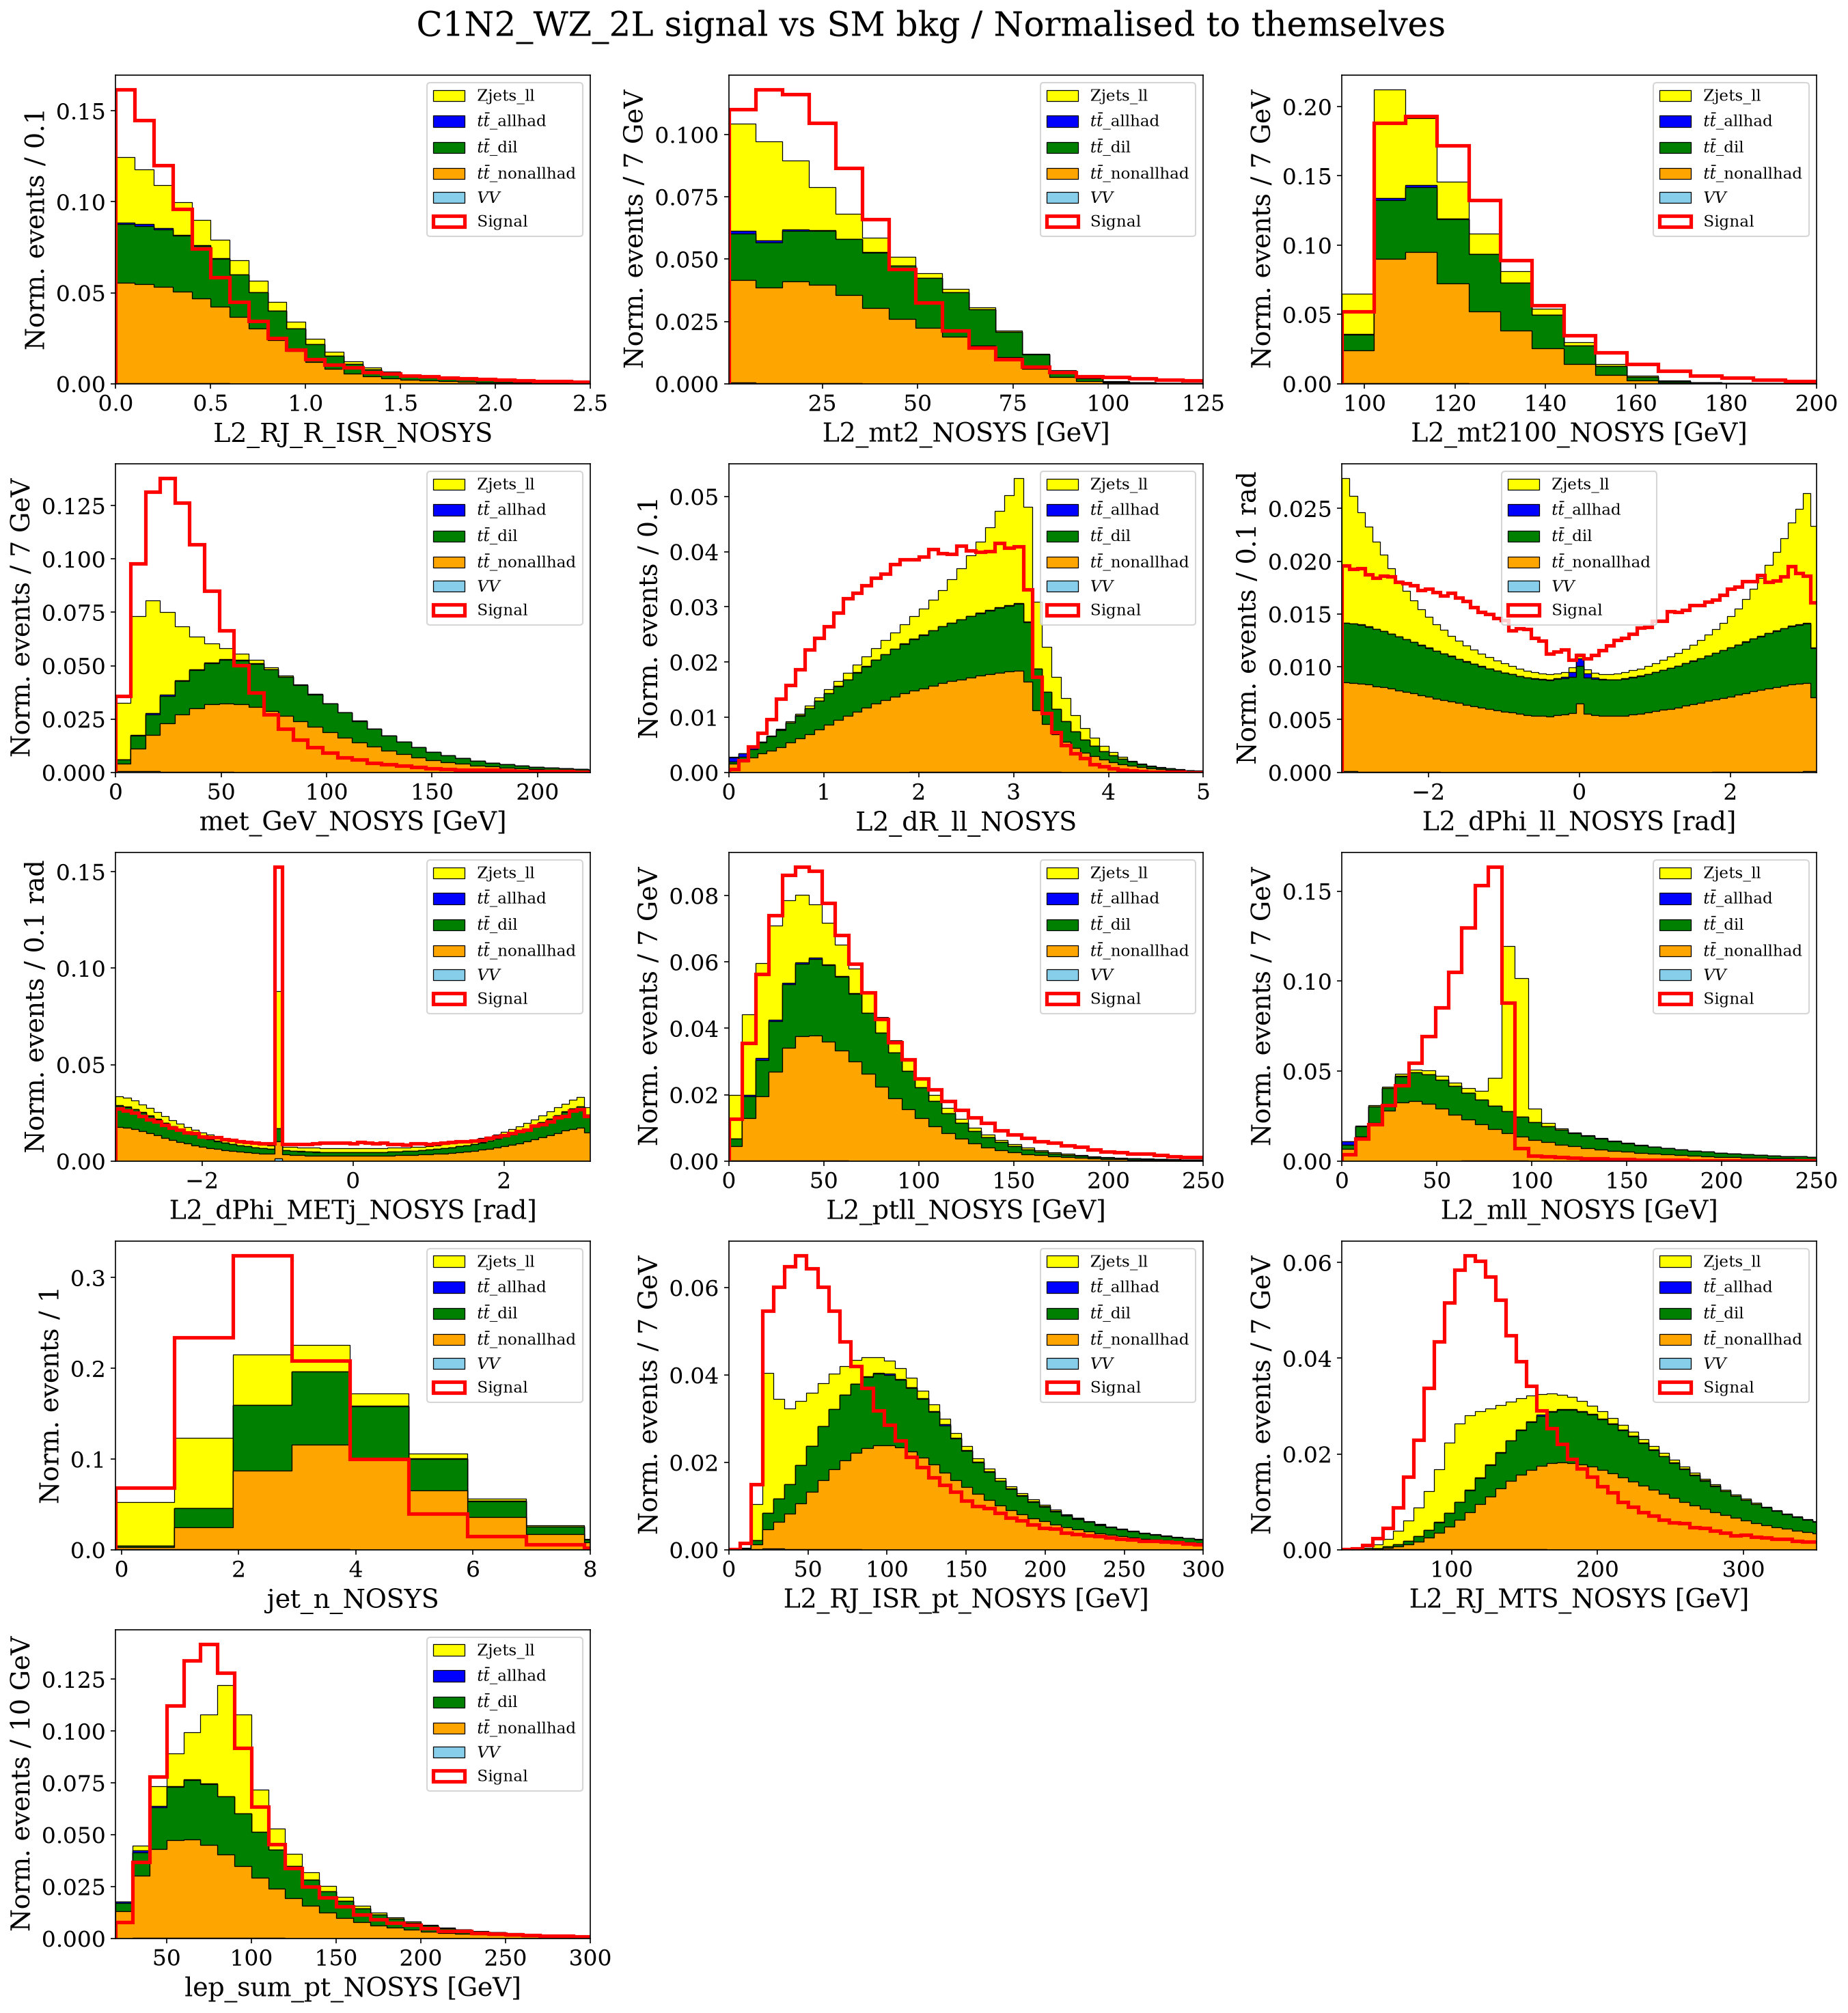

In [19]:
fig1,axes1 = subplot_hist_stack(df=df_tot,variables=variables,title='C1N2_WZ_2L signal vs SM bkg / Normalised to themselves',x_ranges=x_ranges,
                                use_latex=False,wbins_dict=wbins,units_dict=units,norm_to_themselves=True)

save_plot(USER='varom',directory='/nfs/pic.es/user/v/varom/SusyAD_IFAE/Plots',fig=fig1,pdfname='13_07_26_A_StackedFeaturePlots')

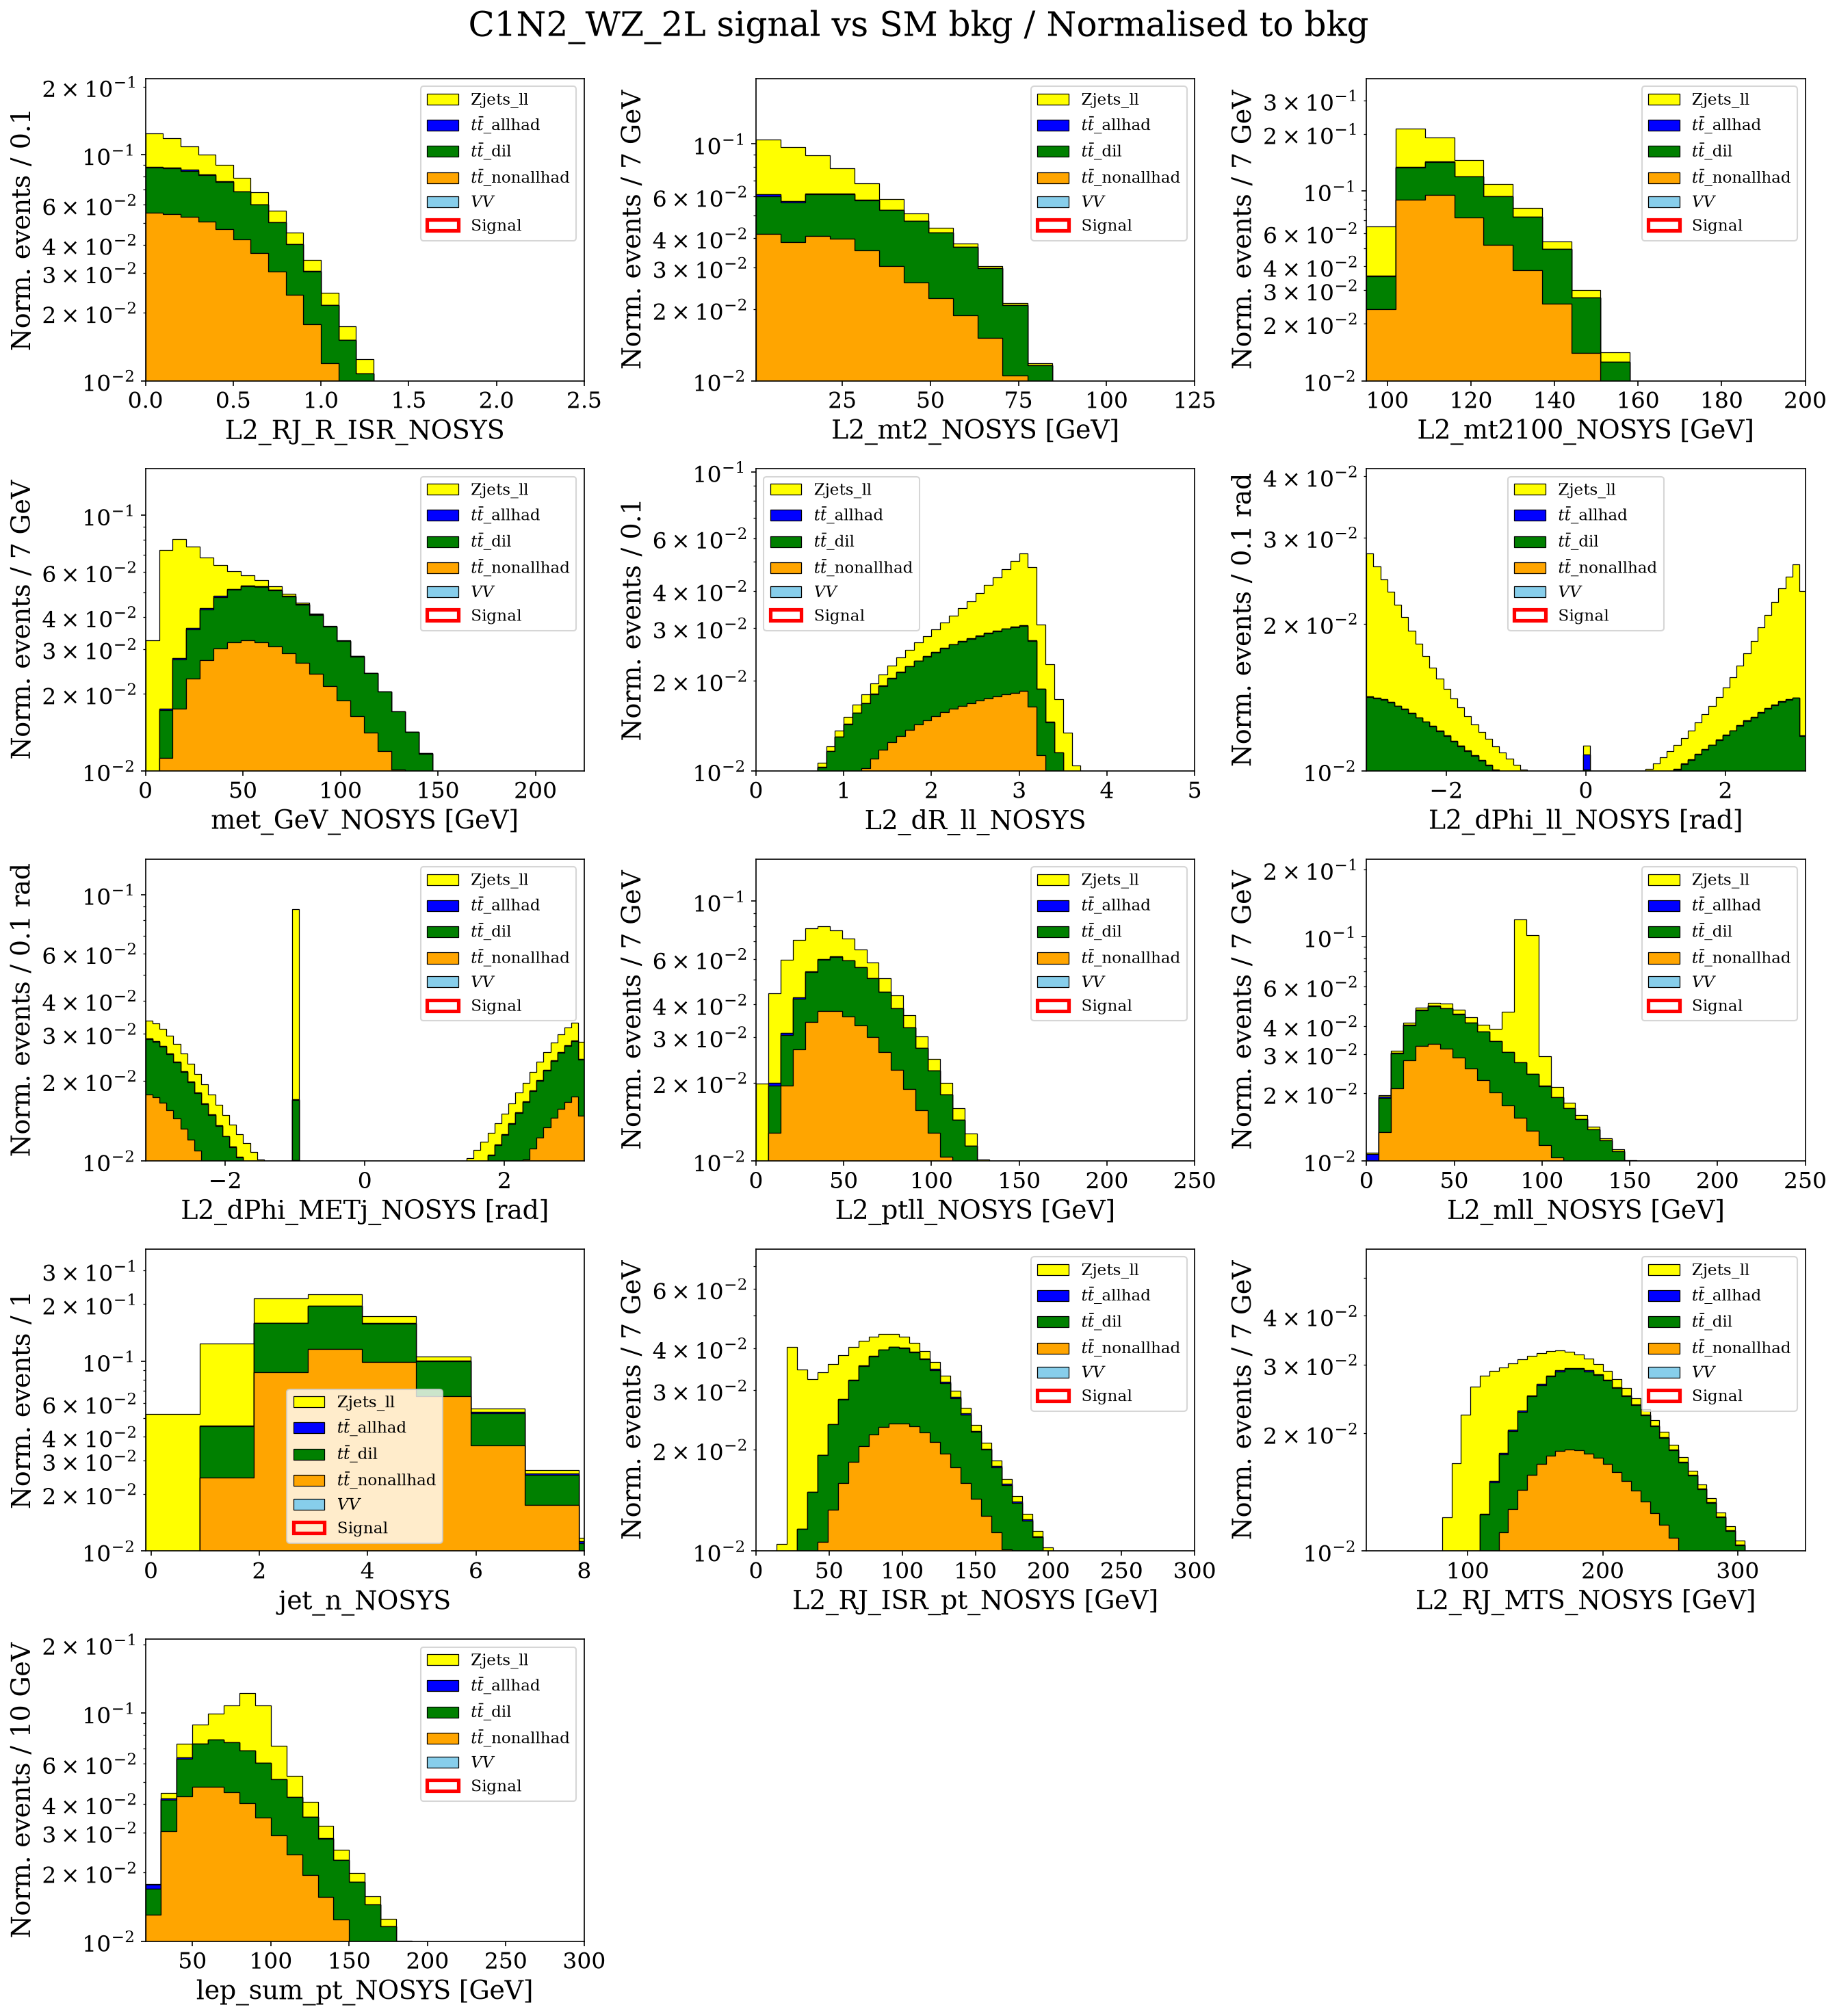

In [ ]:
#fig2,axes2 = subplot_hist_stack(df=df_tot,variables=variables,title='C1N2_WZ_2L signal vs SM bkg / Normalised to bkg',x_ranges=x_ranges,
#                                use_latex=False,wbins_dict=wbins,units_dict=units,norm_to_themselves=False)

#save_plot(USER='varom',directory='/nfs/pic.es/user/v/varom/SusyAD_IFAE/Plots',fig=fig2,pdfname='13_07_26_B_StackedFeaturePlots')